# XGBoost Baseline
Same dataset, same feature set as `build_model_weather.ipynb` (LightGBM) —
the two gradient-boosted tree models are the closest comparison pair in the
chain, since both support native categorical handling and early stopping.
Differences between the two here come down to the boosting implementation
(histogram-based, but different regularization/growth defaults), not
feature engineering.

**Split strategy note:** same as the other notebooks — random group-split by
`trip_id` for the current single-day dataset. Switch `USE_CHRONOLOGICAL_SPLIT`
to `True` once the dataset spans multiple months, and keep this setting
consistent across all baseline notebooks so results stay comparable.

In [14]:
import numpy as np
import polars as pl
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

In [15]:
DATA_PATH = "raw/processed_gtfs/baseline_dataset.parquet"

# Toggle this once the dataset spans multiple months (see note above).
# Requires a `service_date` column in df.
USE_CHRONOLOGICAL_SPLIT = False
CHRONOLOGICAL_SPLIT_DATE = "2026-06-01"  # train < this date, test >= this date

df = pl.read_parquet(DATA_PATH)
print(df.shape)

TARGET = "travel_time"
CATEGORICAL = ["route_id", "direction_id", "shape_id", "service_id", 'is_raining', 'is_snowing', 'is_fog', "is_weekend",
    "is_federal_holiday",
    "is_school_day",
    "has_major_event",]
NUMERIC = [
    "stop_sequence", "trip_progress",
    "hour", "weekday", "month", "is_peak",
    "scheduled_arrival", "scheduled_departure", "scheduled_segment_time",
    "stop_lat", "stop_lon", "latitude", "longitude", "bearing",
    'temperature_c', 'precipitation_mm', 'snowfall_cm', 'windspeed_kmh', 'weathercode',
    'segment_length',
    'scheduled_segment_speed_mps',
    'upstream_delay_seconds',
    'speed_mps',
    'headway_seconds',
    "ridership",
    "transfers",
]

FEATURES = CATEGORICAL + NUMERIC

(56764, 40)


## Split
Identical split logic to `build_model_lr.ipynb` / `build_model_weather.ipynb`
so all baselines are evaluated on the exact same train/test rows.

In [16]:
if USE_CHRONOLOGICAL_SPLIT:
    assert "service_date" in df.columns, "service_date column required for chronological split"

    train_df = df.filter(pl.col("service_date") < CHRONOLOGICAL_SPLIT_DATE)
    test_df = df.filter(pl.col("service_date") >= CHRONOLOGICAL_SPLIT_DATE)

    print(f"[chronological split @ {CHRONOLOGICAL_SPLIT_DATE}]")
    print(f"train: {train_df.shape} | test: {test_df.shape}")
    print(f"train trips: {train_df['trip_id'].n_unique():,} | "
          f"test trips: {test_df['trip_id'].n_unique():,} | "
          f"overlap: {len(set(train_df['trip_id']) & set(test_df['trip_id']))}")
else:
    groups = df["trip_id"].to_numpy()
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(df, groups=groups))

    train_df = df[train_idx]
    test_df = df[test_idx]

    print("[random group split by trip_id]")
    print(f"train: {train_df.shape} | test: {test_df.shape}")
    print(f"train trips: {train_df['trip_id'].n_unique():,} | "
          f"test trips: {test_df['trip_id'].n_unique():,} | "
          f"overlap: {len(set(train_df['trip_id']) & set(test_df['trip_id']))}")

[random group split by trip_id]
train: (45363, 40) | test: (11401, 40)
train trips: 996 | test trips: 250 | overlap: 0


## Convert to pandas
Same helper used in the LightGBM and LR notebooks. XGBoost, like LightGBM,
can consume pandas `category` dtype columns natively (`enable_categorical=True`
below) — no one-hot encoding needed.

In [17]:
def to_pandas_typed(pl_df: pl.DataFrame) -> pd.DataFrame:
    cols = {}
    for col in FEATURES:
        s = pl_df[col]
        if col in CATEGORICAL:
            cols[col] = pd.Series([str(v) for v in s.to_list()], dtype="category")
        else:
            cols[col] = s.to_numpy()
    return pd.DataFrame(cols)

X_train = to_pandas_typed(train_df)
X_test = to_pandas_typed(test_df)
y_train = train_df[TARGET].to_numpy()
y_test = test_df[TARGET].to_numpy()

## Train
`tree_method="hist"` + `enable_categorical=True` is XGBoost's equivalent to
LightGBM's native categorical split handling. Objective/metric
(`reg:absoluteerror` / MAE) and early-stopping setup mirror the LightGBM
notebook so the two are a fair comparison — same loss being optimized, same
patience (50 rounds), same eval set.

In [18]:
model = xgb.XGBRegressor(
    objective="reg:absoluteerror",
    eval_metric="mae",
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=8,
    min_child_weight=30,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    enable_categorical=True,
    early_stopping_rounds=50,
    random_state=42,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100,
)

[0]	validation_0-mae:47.46907
[100]	validation_0-mae:32.47330
[200]	validation_0-mae:31.64443
[300]	validation_0-mae:31.39068
[400]	validation_0-mae:31.24119
[500]	validation_0-mae:31.14553
[600]	validation_0-mae:31.07557
[700]	validation_0-mae:31.04269
[800]	validation_0-mae:31.00541
[900]	validation_0-mae:30.97897
[1000]	validation_0-mae:30.94939
[1100]	validation_0-mae:30.93795
[1200]	validation_0-mae:30.91978
[1300]	validation_0-mae:30.90873
[1400]	validation_0-mae:30.90634
[1500]	validation_0-mae:30.90624


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:absoluteerror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegresso

## Evaluate
Same metrics (MAE, RMSE, R²) and the same naive baseline comparison
(predicting `scheduled_segment_time` as-is) used in the LightGBM notebook,
so the two are directly comparable.

In [19]:
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f"MAE:  {mae:.1f} sec")
print(f"RMSE: {rmse:.1f} sec")
print(f"R2:   {r2:.4f}")
mape = mean_absolute_percentage_error(y_test, preds)
wape = np.abs(y_test - preds).sum() / np.abs(y_test).sum()

print(f"MAPE: {mape*100:.1f}%  (caution: unstable if travel_time has near-zero rows)")
print(f"WAPE: {wape*100:.1f}%")
# naive baseline for comparison: predict the scheduled segment time as-is
naive_preds = test_df["scheduled_segment_time"].to_numpy()
naive_mae = mean_absolute_error(y_test, naive_preds)
print(f"\nNaive baseline (scheduled_segment_time only) MAE: {naive_mae:.1f} sec")
print(f"Improvement over naive: {(1 - mae / naive_mae) * 100:.1f}%")
naive_wape = np.abs(y_test - naive_preds).sum() / np.abs(y_test).sum()
print(f"Naive baseline WAPE: {naive_wape*100:.1f}%")

MAE:  30.9 sec
RMSE: 59.2 sec
R2:   0.4598
MAPE: 63.4%  (caution: unstable if travel_time has near-zero rows)
WAPE: 31.3%

Naive baseline (scheduled_segment_time only) MAE: 47.4 sec
Improvement over naive: 34.8%
Naive baseline WAPE: 48.0%


## Feature importances
Same idea as `feature_importances_` in the LightGBM notebook — here XGBoost's
default "gain"-based importance per feature.

shape: (37, 2)
┌────────────────────────┬────────────┐
│ feature                ┆ importance │
│ ---                    ┆ ---        │
│ str                    ┆ f32        │
╞════════════════════════╪════════════╡
│ segment_length         ┆ 0.087644   │
│ transfers              ┆ 0.072411   │
│ hour                   ┆ 0.061381   │
│ scheduled_segment_time ┆ 0.041042   │
│ stop_lat               ┆ 0.040539   │
│ …                      ┆ …          │
│ is_weekend             ┆ 0.0        │
│ is_federal_holiday     ┆ 0.0        │
│ is_school_day          ┆ 0.0        │
│ has_major_event        ┆ 0.0        │
│ snowfall_cm            ┆ 0.0        │
└────────────────────────┴────────────┘


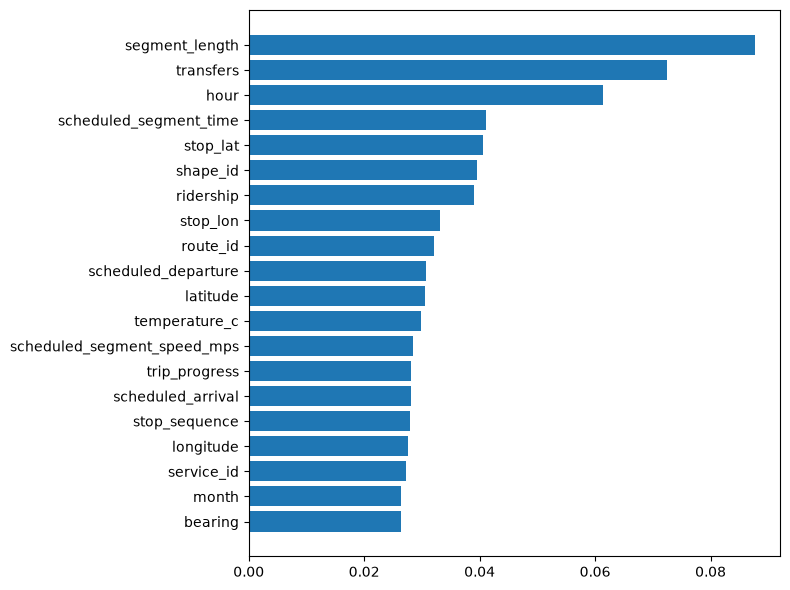

In [20]:
importance = (
    pl.DataFrame({
        "feature": X_train.columns.tolist(),
        "importance": model.feature_importances_,
    })
    .sort("importance", descending=True)
)
print(importance)

import matplotlib.pyplot as plt

top = importance.head(20).to_pandas()
plt.figure(figsize=(8, 6))
plt.barh(top["feature"], top["importance"])
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Save
Saved via XGBoost's native `save_model` as `.json` (XGBoost's recommended
format — portable across versions, unlike pickling the sklearn wrapper).
Naming mirrors the LightGBM `.txt` booster dump so the two are easy to pair
up in `models/`.

In [ ]:
# model.save_model("models/xgb_weather_segments_delay_and_ridership.json")
# print("model saved")

model saved
